This is based on the Skeleton.ipynb Notebook
check:


https://bitbucket.imp.ac.at/users/ulises.rey/repos/skeleton/browse

### ReadME -IMPORTANT!
I have now rewritten it in a better way. This is written at the top of this notebook.
Old code can be found further down into the notebook.

In [2]:
#import pckgs
import cv2
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import csv 

import os
from natsort import natsorted

from scipy.interpolate import splprep, splev

from skimage.morphology import medial_axis, skeletonize
from skimage import data
from skimage.util import invert
import skimage.graph

import scipy.fftpack

In [4]:
#define shortest_path function (new version)
#costs has the image with the costs on each step (default was the square of the dist. transformation)
def shortest_path2(start,end,binary,costs):
    path, cost = skimage.graph.route_through_array(costs, start=start, end=end, fully_connected=True)
    return path,cost
#define shortest_path function
def shortest_path(start,end,binary):
    costs=np.where(binary,1,1000)
    path, cost = skimage.graph.route_through_array(costs, start=start, end=end, fully_connected=True)
    return path,cost,costs

In [ ]:
#define default output path
output_path='/groups/zimmer/Ulises/code/skeleton_outputs/'
try: os.mkdir(output_path)
except: print('Output Directory already exists')

### First generate binary image

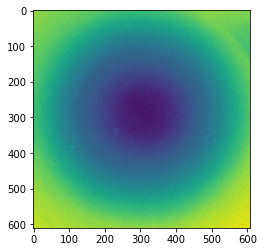

In [15]:
#read and write tiff video

output_filename='/groups/zimmer/Ulises/code/skeleton_outputs/2020-06-05_16-46-41_worm1-channel-0-binary.tiff'

input_filename='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_btf/2020-06-05_16-46-41_worm1-channel-0-bigtiff.btf'

bg_img= tiff.imread('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/datasets/dataset_20200605/2020-06-05_16-46-41_worm1-channel-0-/2020-06-05_16-46-41_worm1-channel-0-copied_bg/2020-06-09_10-21-16_control_worm1_bg-channel-0-_MMStack_Median_BG.tiff')

with tiff.TiffWriter(output_filename, bigtiff=True) as tif_writer:
    with tiff.TiffFile(input_filename, multifile=False) as tif:
        for i, page in enumerate(tif.pages):
            #loads the first frame and inverts it
            img=page.asarray()
            img=cv2.bitwise_not(img)
            
            #substrack background
            img=cv2.subtract(img,bg_img)
            
            #median Blur
            img[:] = cv2.medianBlur(img,5)
            
            #apply threshold
            ret, new_img = cv2.threshold(img,11,255,cv2.THRESH_BINARY)
            
            #find contours
            contours = cv2.findContours(new_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            contours = contours[0] if len(contours) == 2 else contours[1]
            
            #list areas of contours, find MAX, draw contours from MAX area
            areas=[]
            for j in range(0, len(contours)):
                areas.append(cv2.contourArea(contours[j]))
            worm_contour=np.where(areas==np.asarray(areas).max())
            worm_contour=np.asarray(worm_contour)
            img_contours = np.zeros(img.shape)
            img[:]=cv2.drawContours(img_contours,contours, worm_contour, 255, -1)

            tif_writer.save(img)

### Then generate skeleton

In [6]:
#read binary tiff video
input_filename='/groups/zimmer/Ulises/code/skeleton_outputs/binary_bigtiff/2020-06-05_16-46-41_worm1-channel-0-binary_bigtiff.tiff'

#read coordinates from DLC
h5_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_avi/'
h5_file='2020-06-05_16-46-41_worm1-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_590000.h5'
h5_filepath=os.path.join(h5_path,h5_file)
print(h5_filepath)

df = pd.read_hdf(h5_filepath)

scorer=df.columns.get_level_values(0)[0]
head_x=df[scorer]['Head']['x'].values
head_y=df[scorer]['Head']['y'].values
tail_x=df[scorer]['Tail']['x'].values
tail_y=df[scorer]['Tail']['y'].values


#create csv objects
output_path='/groups/zimmer/Ulises/code/skeleton_outputs/new'

csvfileX=open(os.path.join(output_path,'spline_X_coords.csv'),'w', newline='')
csv_writerX=csv.writer(csvfileX)

csvfileY=open(os.path.join(output_path,'spline_Y_coords.csv'),'w', newline='')
csv_writerY=csv.writer(csvfileY)

csvfileK=open(os.path.join(output_path,'spline_K.csv'),'w', newline='')
csv_writerK=csv.writer(csvfileK)

knots=100

with tiff.TiffFile(input_filename, multifile=False) as tif:
    for i, page in enumerate(tif.pages):
        img=page.asarray()
        #plt.imshow(img)
        #plt.show()
        skeleton = skeletonize(img/255)
        skeleton=np.asarray(skeleton, dtype="uint8")

        #this defines the costs for the shortest path
        costs=cv2.distanceTransform(img, cv2.DIST_L2,3)
        cv2.normalize(costs, costs, 0, 255, cv2.NORM_MINMAX)
        costs=costs**2
        costs=costs.max()-costs

        #Scikit graph approach - Shortest Path

        ### give start (y1,x1) and end (y2,x2) and the binary maze image as input
        #shortest path
        #print('index was changed from k to i, double check that it works')
        start_point =  (int(head_y[i]), int(head_x[i]))#(286, 124)#
        end_point = (int(tail_y[i]), int(tail_x[i]))#(332,480)#
        #print(start_point, end_point)

        #Shortest Path default:

        path, cost, costs=shortest_path(start_point, end_point, skeleton)

        #somehow the coordinates are the other way around
        #y, x = zip(*path)

        #My new shortest path function:
        #I modified the original shortest_path function, now costs are defined outside
        #it works on the img instead of the skeleton, which is in fact not used
        #path, cost=shortest_path2(start_point, end_point, img, costs)
        #it didnt work very well in some frame so I went back to the original:

        pts=np.asarray(path, dtype=np.int)

        ####
        #s is the smoothing condition should have around the size of points/2 (keep it low)
        #k is the degree of freedom for the polynom it fits, 5 is good
        #splprep calculates automatically the number of knots. One can see how many in tck.shape[1].
        #everytime splprep is run the number by differ
        tck, u = splprep(pts.T, u=None, s=pts.shape[0]/2, per=0, k=5) 
        u_new = np.linspace(u.min(), u.max(), knots)#1000)

        x_new, y_new = splev(u_new, tck, der=0)

        #this returns x'(s), y'(s)
        x_der, y_der = splev(u_new, tck, der=1)
        #to have y'(x):
        der=y_der/x_der

        #this returns x''(s), y''(s)
        x_der2, y_der2 = splev(u_new, tck, der=2)
        #to have y''(x), also called K for Curvature:
        #we need the following equation:
        #ref in: https://en.wikipedia.org/wiki/Curvature#In_terms_of_a_general_parametrization (1st equation)
        K=(x_der*y_der2-y_der*x_der2)/np.sqrt(x_der**2+y_der**2)**3

        #csv writer
        csv_writerX.writerow(x_new)
        csv_writerY.writerow(y_new)
        csv_writerK.writerow(K)

        if i==600:
            break
    #print('writing...')
csvfileX.close()
csvfileY.close()
csvfileK.close()

/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_avi/2020-06-05_16-46-41_worm1-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_590000.h5


## Plottting Derivative

In [ ]:
for frame, k_v in enumerate(all_K):
    x_new=all_x_new[frame]
    y_new=all_y_new[frame]
    der=all_der[frame]
    K=all_K[frame]

    x_cord=np.arange(0,100,1)

    plt.figure(figsize=(20,10))
    r,c=2,2
    # ax1=plt.subplot(r,c,1)
    # plt.plot(x_cord, y_new, 'bo')
    # plt.title('Worm')

    #first der
    ax3=plt.subplot(r,c,1)
    #plt.plot(x_cord,der)
    plt.scatter(x_cord, der, c=der, marker='.', cmap='bwr', vmin=-2, vmax=2)
    ax3.set_ylim(-5, 5)

    plt.axhline(y=0, xmin=0, xmax=1)
    #ax3.set_ylim(-2, 2)
    #ax3.set_xlim(400, 450)
    plt.title('First Derivative')

    ax5=plt.subplot(r,c,2)
    #plt.plot(x_new, der2, 'o')
    plt.scatter(x_cord, K, c=K, marker='.', cmap='bwr', vmin=-0.02, vmax=0.02)#, vmin=-5000, vmax=5000)#y_der2, marker='.', cmap='bwr')
    ax5.set_ylim(-0.1, 0.1)

    plt.axhline(y=0, xmin=0, xmax=1)
    plt.title('Second Derivative')

    #worm first der
    ax2=plt.subplot(r,c,3)
    sc=plt.scatter(x_new, y_new, c=der, marker='.', cmap='bwr', vmin=-2, vmax=2)
    #plt.colorbar(sc)
    plt.title('Color coded worm from First Derivative')



    ax4=plt.subplot(r,c,4)
    sc=plt.scatter(x_new, y_new, c=K, marker='.', cmap='bwr', vmin=-0.02, vmax=0.02)#y_der2, marker='.', cmap='bwr')
    #plt.colorbar(sc)
    plt.title('Color coded worm from Second Derivative')
    plt.savefig('derivatives/'+str(frame)+'.tiff')
    plt.close()

# PCA part

In [ ]:

#after: https://towardsdatascience.com/pca-using-python-scikit-learn-e653f8989e60
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler




In [ ]:
path='/groups/zimmer/Ulises/code/skeleton_OLD/'
df=pd.read_csv(path+'second_der_np_new.csv', header=None)
df.shape

In [ ]:
pca = PCA(n_components=5)
principalComponents = pca.fit_transform(df)
principalComponents.shape
principalDf = pd.DataFrame(data = principalComponents
             , columns = ['PC1', 'PC2','PC3','PC4','PC5'])

In [ ]:
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(df)
principalComponents.shape
principalDf = pd.DataFrame(data = principalComponents
             , columns = ['PC1', 'PC2'])

In [ ]:
principalComponents.shape

In [ ]:
plt.figure(figsize=(14,7))
plt.plot(principalDf['PC1'][3000:4000])
plt.plot(principalDf['PC2'][3000:4000])

In [ ]:
principalDf.index

In [ ]:
fig = principalDf.plot.scatter(x='PC1', y='PC2',c=principalDf.index, colormap='viridis')
fig= principalDf.plot(x='PC1', y='PC2')
fig.set_xlim([-1,1])
fig.set_ylim([-1,1])

In [ ]:
plt.figure(figsize=(7,7))
for k,d in principalDf:
    plt.scatter(k,d)
#plt.scatter(principalDf['PC1'][0:10],principalDf['PC2'][0:10])
#plt.plot(principalDf['PC2'][3000:4000])

In [ ]:
k,d=principalDf

In [ ]:
d

In [ ]:
plt.scatter(principalDf['PC1'][0:4000],principalDf['PC2'][0:4000],c=np.arange(0,4000), vmin=0, vmax=4000)
plt.colorbar()
# ax_lim=0.2
# plt.xlim(-ax_lim,ax_lim)
# plt.ylim(-ax_lim,ax_lim)

In [ ]:
plt.figure(figsize=(14,10))
plt.hist2d(principalDf['PC1'],principalDf['PC2'], bins=1000)
plt.colorbar()
ax_lim=.2
plt.xlim(-ax_lim,ax_lim)
plt.ylim(-ax_lim,ax_lim)

In [ ]:
plt.scatter(principalDf['PC1'],principalDf['PC3'],marker='.')
plt.xlim(-.5,.5)
plt.ylim(-.5,.5)

In [ ]:
plt.scatter(principalDf['PC1'],principalDf['PC4'],marker='.')
plt.xlim(-.5,.5)
plt.ylim(-.5,.5)